In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import warnings
from pathlib import Path

In [35]:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.selection import select_features_lasso, get_permutation_importance, get_shap_values
from src.evaluate import create_cv_splits, cross_validate

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

with open(PROJECT_ROOT / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

train_df = pd.read_json(config["paths"]["processed_train"])
test_df = pd.read_json(config["paths"]["processed_test"])

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

Train: (16102, 44)
Test: (32277, 43)


## Подготовка данных с полиномиальными признаками

In [36]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

target = "price"

exclude_columns = [
    target, "created", "features", "features_cleaned",
    "interest_level", "num_features_raw", "building_id"
]

feature_list = [
    col for col in train_df.columns
    if col not in exclude_columns
    and train_df[col].dtype in ['int64', 'float64']
]

X_train = train_df[feature_list].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_list].copy()
y_test = test_df[target].copy()

print(f"\nИсходное количество признаков: {len(feature_list)}")

# Создание полиномиальных признаков
poly = PolynomialFeatures(degree=2, include_bias=False) #Используем degree=2, чтобы избежать переобучения при малом количестве исходных признаков.
poly_features = poly.fit_transform(X_train[['bathrooms', 'bedrooms']])
poly_feature_names = poly.get_feature_names_out(['bathrooms', 'bedrooms'])

print(f"\nПолиномиальные признаки (degree=2):") 
for i, name in enumerate(poly_feature_names, 1):
    print(f"  {i:2d}. {name}")

poly_feature_names_renamed = [f"poly_{name}" for name in poly_feature_names]

# Создаем DataFrame с переименованными колонками
X_train_poly = pd.DataFrame(
    poly_features, 
    columns=poly_feature_names_renamed, 
    index=X_train.index
)
X_test_poly = pd.DataFrame(
    poly.transform(X_test[['bathrooms', 'bedrooms']]), 
    columns=poly_feature_names_renamed, 
    index=X_test.index
)

# Объединяем
X_train_full = pd.concat([X_train, X_train_poly], axis=1)
X_test_full = pd.concat([X_test, X_test_poly], axis=1)

# Защитная проверка на дубликаты
duplicates = X_train_full.columns[X_train_full.columns.duplicated()]
if len(duplicates) > 0:
    raise ValueError(f"Обнаружены дубликаты колонок: {list(duplicates)}")

print(f"\nИтоговое количество признаков: {X_train_full.shape[1]}")
print(f"Размер X_train: {X_train_full.shape}")
print(f"Размер X_test: {X_test_full.shape}")

# === Масштабирование ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

print(f"\nStandardScaler применен")


Исходное количество признаков: 32

Полиномиальные признаки (degree=2):
   1. bathrooms
   2. bedrooms
   3. bathrooms^2
   4. bathrooms bedrooms
   5. bedrooms^2

Итоговое количество признаков: 37
Размер X_train: (16102, 37)
Размер X_test: (32277, 37)

StandardScaler применен


## Feature Selection - Lasso L1


Оптимальный alpha (LassoCV): 98.8845

Всего признаков: 37
Отобрано признаков: 8


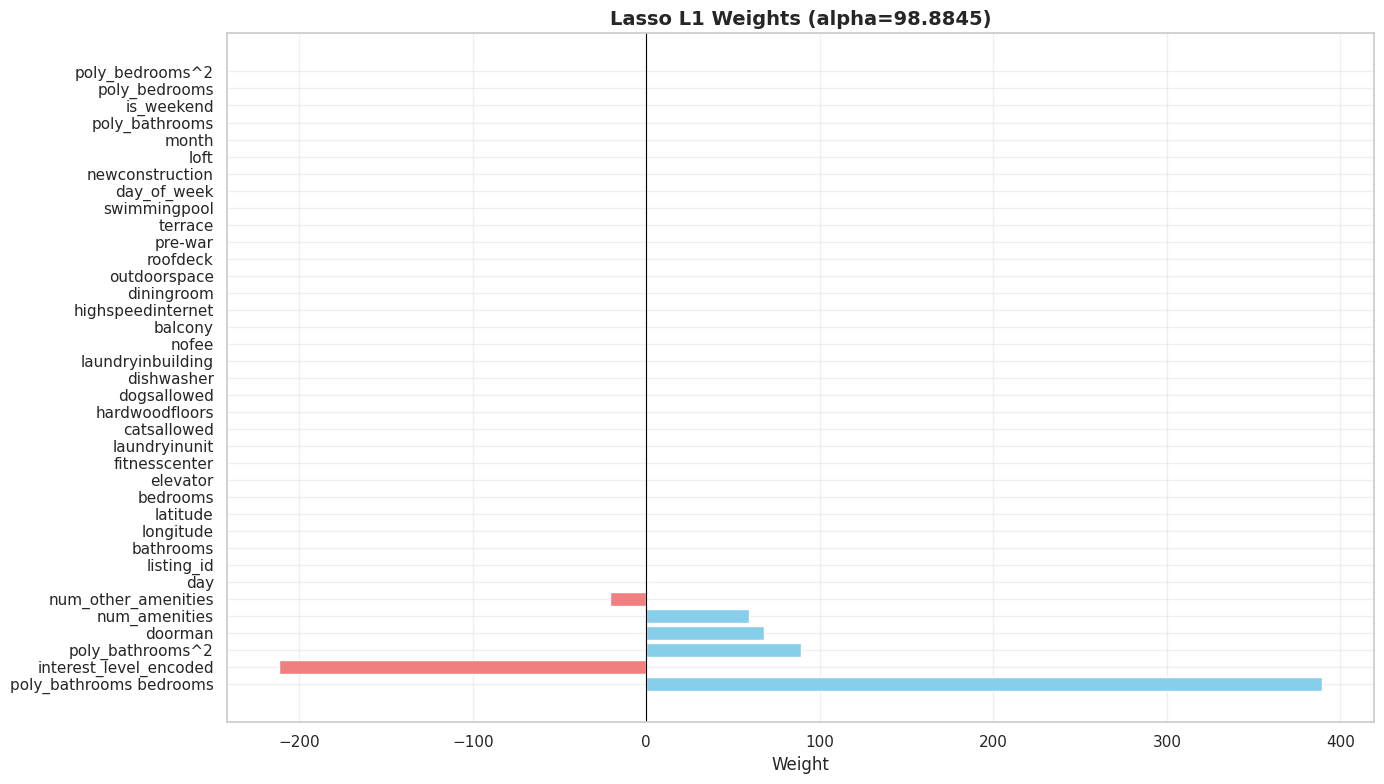


Топ-10 признаков по Lasso:
   1. listing_id
   2. doorman
   3. num_other_amenities
   4. num_amenities
   5. interest_level_encoded
   6. day
   7. poly_bathrooms^2
   8. poly_bathrooms bedrooms


In [37]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

print(f"\nОптимальный alpha (LassoCV): {lasso_cv.alpha_:.4f}")

lasso_result = select_features_lasso(
    X_train_full, y_train, 
    alpha=lasso_cv.alpha_, 
    random_state=42
)

print(f"\nВсего признаков: {lasso_result['n_total']}")
print(f"Отобрано признаков: {lasso_result['n_selected']}")

weights_df = pd.DataFrame([
    {'feature': name, 'weight': weight}
    for name, weight in lasso_result['weights'].items()
])
weights_df = weights_df.sort_values('weight', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['lightcoral' if w < 0 else 'skyblue' for w in weights_df['weight']]
ax.barh(range(len(weights_df)), weights_df['weight'].values, color=colors)
ax.set_yticks(range(len(weights_df)))
ax.set_yticklabels(weights_df['feature'].values)
ax.set_xlabel('Weight')
ax.set_title(f'Lasso L1 Weights (alpha={lasso_cv.alpha_:.4f})', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

top_10_features = lasso_result['selected_features'][:10]
print(f"\nТоп-10 признаков по Lasso:")
for i, feat in enumerate(top_10_features, 1):
    print(f"  {i:2d}. {feat}")

## Permutation Importance


Топ-10 признаков по Permutation Importance:
       feature  importance_mean  importance_std
1   feature_35        85.496224        2.609402
2    feature_9        80.823778        2.042050
3   feature_27        53.833037        2.077119
4    feature_0        48.893627        2.561514
5   feature_32        48.893627        2.561514
6   feature_33        36.214944        1.212497
7    feature_1        36.214944        1.212497
8   feature_14        33.169644        1.052967
9   feature_26        26.363052        1.581239
10   feature_4        14.597871        0.231417


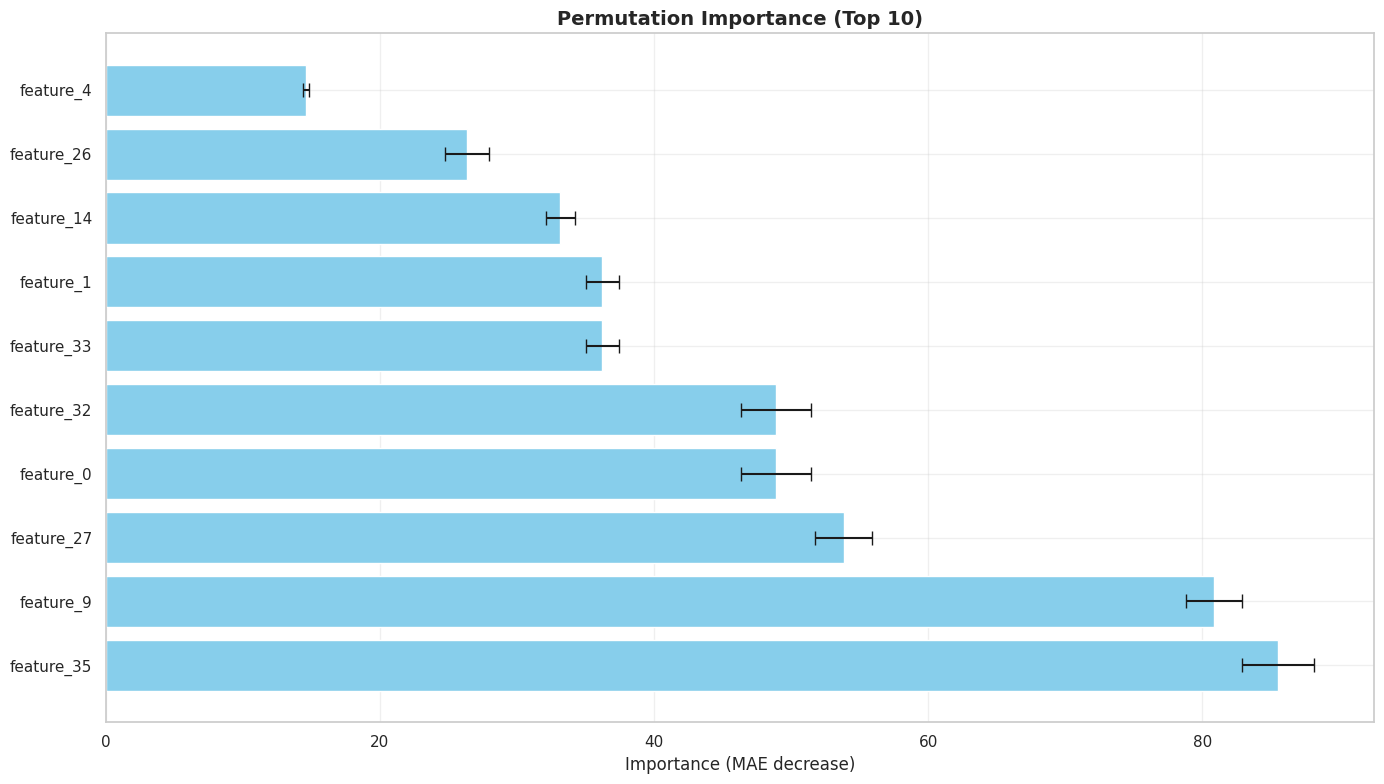

In [38]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

perm_df = get_permutation_importance(
    ridge_model, X_train_scaled, y_train, 
    n_repeats=10, random_state=42
)

print("\nТоп-10 признаков по Permutation Importance:")
print(perm_df.head(10).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
top_10_perm = perm_df.head(10)
ax.barh(
    range(len(top_10_perm)), 
    top_10_perm['importance_mean'].values, 
    xerr=top_10_perm['importance_std'].values, 
    color='skyblue', capsize=5
)
ax.set_yticks(range(len(top_10_perm)))
ax.set_yticklabels(top_10_perm['feature'].values)
ax.set_xlabel('Importance (MAE decrease)')
ax.set_title('Permutation Importance (Top 10)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP Values

  0%|          | 0/100 [00:00<?, ?it/s]


Топ-10 признаков по SHAP:
       feature  shap_value
1    feature_9  283.485885
2   feature_27  182.961492
3   feature_35  181.476177
4   feature_32  130.317292
5    feature_0  130.057311
6    feature_1  115.684650
7   feature_33  112.328556
8   feature_14  104.211699
9    feature_5   74.398682
10  feature_26   52.670809


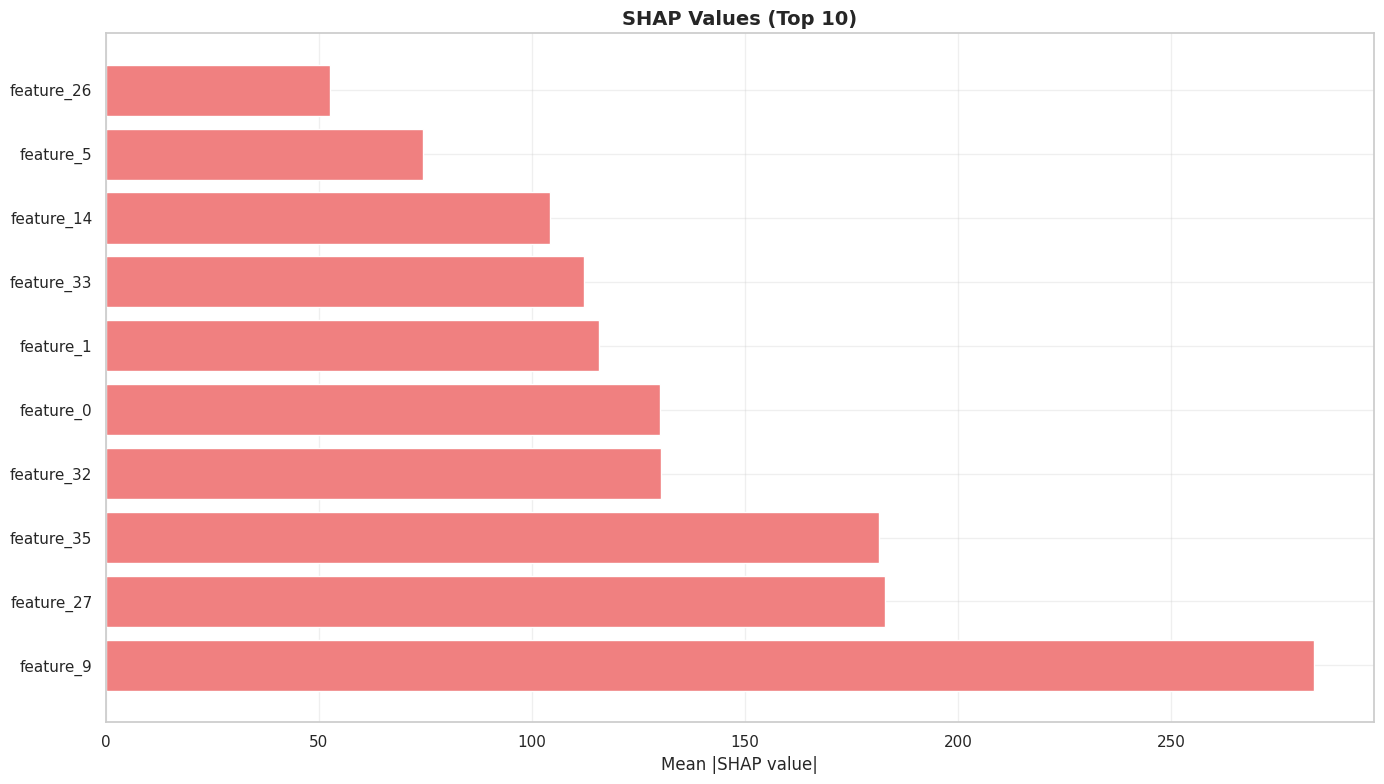

In [39]:
shap_df = get_shap_values(ridge_model, X_train_scaled, n_samples=100, random_state=42)

print("\nТоп-10 признаков по SHAP:")
print(shap_df.head(10).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
top_10_shap = shap_df.head(10)
ax.barh(range(len(top_10_shap)), top_10_shap['shap_value'].values, color='lightcoral')
ax.set_yticks(range(len(top_10_shap)))
ax.set_yticklabels(top_10_shap['feature'].values)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Values (Top 10)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cross-Validation стратегии


K-Fold (5 folds):
  Mean MAE: $689.22
  Std MAE:  $9.48

Time Series Split (5 folds):
  Mean MAE: $685.82
  Std MAE:  $19.44

Group K-Fold (5 folds, by building_id):
  Mean MAE: $695.50
  Std MAE:  $15.45

Сравнение CV стратегий:
      Method  Mean MAE ($)  Std MAE ($)
      K-Fold    689.216534     9.478019
 Time Series    685.816258    19.443129
Group K-Fold    695.500956    15.453857


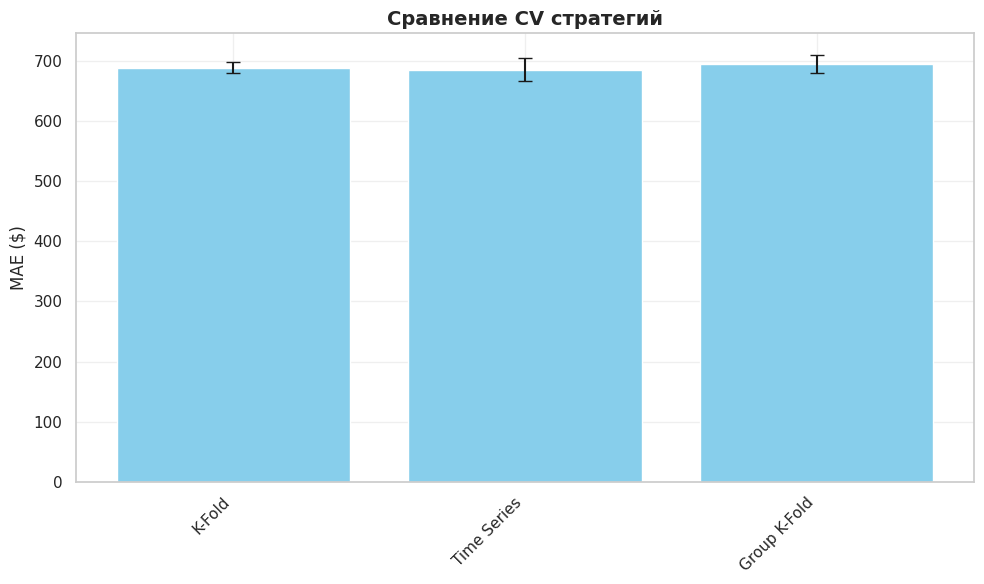

In [40]:
from sklearn.model_selection import KFold, GroupKFold, TimeSeriesSplit
from sklearn.model_selection import cross_val_score

groups = train_df['building_id'].values if 'building_id' in train_df.columns else None

results_cv = {}

# K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(
    Ridge(alpha=1.0), X_train_scaled, y_train, 
    cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1
)
results_cv['K-Fold'] = (-np.mean(kf_scores), np.std(kf_scores))
print(f"\nK-Fold (5 folds):")
print(f"  Mean MAE: ${results_cv['K-Fold'][0]:.2f}")
print(f"  Std MAE:  ${results_cv['K-Fold'][1]:.2f}")

# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)
ts_scores = cross_val_score(
    Ridge(alpha=1.0), X_train_scaled, y_train, 
    cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
)
results_cv['Time Series'] = (-np.mean(ts_scores), np.std(ts_scores))
print(f"\nTime Series Split (5 folds):")
print(f"  Mean MAE: ${results_cv['Time Series'][0]:.2f}")
print(f"  Std MAE:  ${results_cv['Time Series'][1]:.2f}")

# Group K-Fold
if groups is not None:
    gkf = GroupKFold(n_splits=5)
    group_scores = cross_val_score(
        Ridge(alpha=1.0), X_train_scaled, y_train, 
        cv=gkf, scoring='neg_mean_absolute_error', 
        groups=groups, n_jobs=-1
    )
    results_cv['Group K-Fold'] = (-np.mean(group_scores), np.std(group_scores))
    print(f"\nGroup K-Fold (5 folds, by building_id):")
    print(f"  Mean MAE: ${results_cv['Group K-Fold'][0]:.2f}")
    print(f"  Std MAE:  ${results_cv['Group K-Fold'][1]:.2f}")

cv_df = pd.DataFrame({
    'Method': list(results_cv.keys()),
    'Mean MAE ($)': [v[0] for v in results_cv.values()],
    'Std MAE ($)': [v[1] for v in results_cv.values()]
})

print("\nСравнение CV стратегий:")
print(cv_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(cv_df))
ax.bar(
    x_pos, cv_df['Mean MAE ($)'].values, 
    yerr=cv_df['Std MAE ($)'].values, 
    color='skyblue', capsize=5
)
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Method'].values, rotation=45, ha='right')
ax.set_ylabel('MAE ($)')
ax.set_title('Сравнение CV стратегий', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning - GridSearch

In [41]:
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from tqdm.notebook import tqdm
import time

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = ParameterGrid(param_grid)
best_score_grid = float('inf')
best_params_grid = None
best_model_grid = None

print("Запуск GridSearch...")
pbar = tqdm(grid, desc="GridSearch", unit="комбинация", total=len(grid))

start_time = time.time()
for params in pbar:
    model = ElasticNet(**params, random_state=42, max_iter=10000)
    
    scores = cross_val_score(
        model, X_train_scaled, y_train, 
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mean_score = -scores.mean()
    
    elapsed_time = time.time() - start_time
    pbar.set_postfix({"MAE": f"{mean_score:.2f}", "Время": f"{elapsed_time:.1f}с"})
    
    if mean_score < best_score_grid:
        best_score_grid = mean_score
        best_params_grid = params
        best_model_grid = model

print(f"\nGridSearch завершен.")
print(f"Лучшие гиперпараметры: {best_params_grid}")
print(f"Лучший CV MAE: ${best_score_grid:.2f}")

best_model_grid.fit(X_train_scaled, y_train)
y_test_pred_grid = best_model_grid.predict(X_test_scaled)
test_mae_grid = mean_absolute_error(y_test, y_test_pred_grid)
print(f"Test MAE: ${test_mae_grid:.2f}")

Запуск GridSearch...


GridSearch:   0%|          | 0/25 [00:00<?, ?комбинация/s]


GridSearch завершен.
Лучшие гиперпараметры: {'alpha': 0.001, 'l1_ratio': 0.9}
Лучший CV MAE: $687.72
Test MAE: $676.60


## Hyperparameter Tuning - RandomSearch

In [42]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform

param_dist = {
    'alpha': uniform(0.001, 10),
    'l1_ratio': uniform(0, 1)
}

n_iter = 50
random_grid = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=42))

best_score_random = float('inf')
best_params_random = None
best_model_random = None

print("Запуск RandomSearch...")
pbar = tqdm(random_grid, desc="RandomSearch", unit="комбинация", total=n_iter)

start_time = time.time()
for params in pbar:
    model = ElasticNet(**params, random_state=42, max_iter=10000)
    
    scores = cross_val_score(
        model, X_train_scaled, y_train, 
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mean_score = -scores.mean()
    
    elapsed_time = time.time() - start_time
    pbar.set_postfix({"MAE": f"{mean_score:.2f}", "Время": f"{elapsed_time:.1f}с"})
    
    if mean_score < best_score_random:
        best_score_random = mean_score
        best_params_random = params
        best_model_random = model

print(f"\nRandomSearch завершен.")
print(f"Лучшие гиперпараметры:")
print(f"  Alpha: {best_params_random['alpha']:.4f}")
print(f"  L1 Ratio: {best_params_random['l1_ratio']:.4f}")
print(f"Лучший CV MAE: ${best_score_random:.2f}")

best_model_random.fit(X_train_scaled, y_train)
y_test_pred_random = best_model_random.predict(X_test_scaled)
test_mae_random = mean_absolute_error(y_test, y_test_pred_random)
print(f"Test MAE: ${test_mae_random:.2f}")

Запуск RandomSearch...


RandomSearch:   0%|          | 0/50 [00:00<?, ?комбинация/s]


RandomSearch завершен.
Лучшие гиперпараметры:
  Alpha: 0.2068
  L1 Ratio: 0.9699
Лучший CV MAE: $688.54
Test MAE: $677.37


## Hyperparameter Tuning - Optuna

Запуск Optuna...


Optuna:   0%|          | 0/50 [00:00<?, ?trial/s]


Optuna завершен.
Лучшие гиперпараметры:
  Alpha: 0.000019
  L1 Ratio: 0.9992
Best CV MAE: $689.21
Test MAE: $676.60


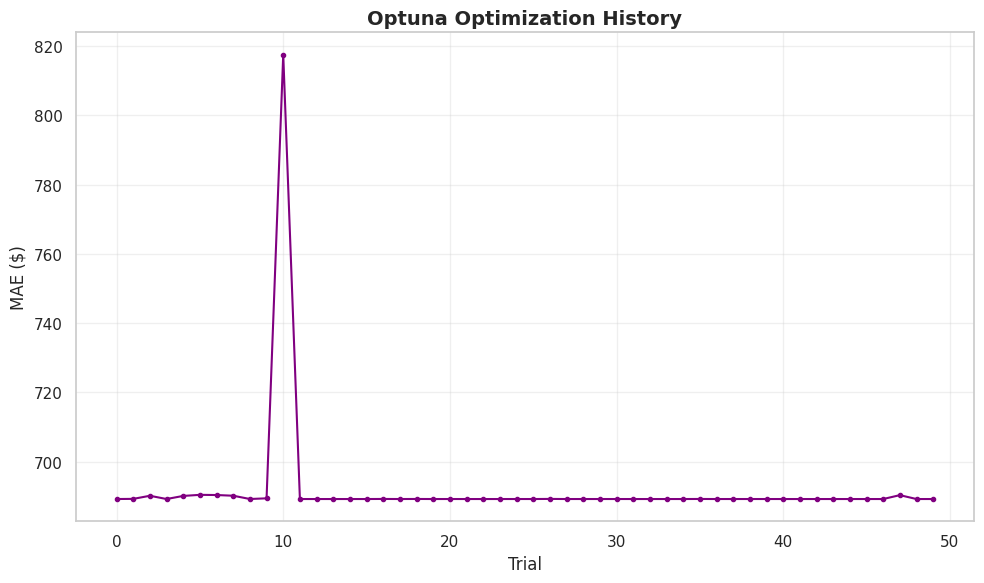

In [43]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 10, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
    
    model = ElasticNet(
        alpha=alpha, l1_ratio=l1_ratio, 
        max_iter=10000, random_state=42
    )
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_scaled, y_train, 
        cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    
    return -scores.mean()

study = optuna.create_study(direction='minimize')
n_trials = 50

print("Запуск Optuna...")
start_time = time.time()
pbar = tqdm(range(n_trials), desc="Optuna", unit="trial", total=n_trials)

for _ in pbar:
    study.optimize(objective, n_trials=1, show_progress_bar=False)
    
    best_val = study.best_value
    elapsed_time = time.time() - start_time
    pbar.set_postfix({"Best MAE": f"{best_val:.2f}", "Время": f"{elapsed_time:.1f}с"})

print(f"\nOptuna завершен.")
print(f"Лучшие гиперпараметры:")
print(f"  Alpha: {study.best_params['alpha']:.6f}")
print(f"  L1 Ratio: {study.best_params['l1_ratio']:.4f}")
print(f"Best CV MAE: ${study.best_value:.2f}")

best_model_optuna = ElasticNet(
    alpha=study.best_params['alpha'],
    l1_ratio=study.best_params['l1_ratio'],
    max_iter=10000,
    random_state=42
)
best_model_optuna.fit(X_train_scaled, y_train)
y_test_pred_optuna = best_model_optuna.predict(X_test_scaled)
test_mae_optuna = mean_absolute_error(y_test, y_test_pred_optuna)
print(f"Test MAE: ${test_mae_optuna:.2f}")

# Визуализация истории оптимизации
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([t.value for t in study.trials], marker='o', markersize=3, color='purple')
ax.set_xlabel('Trial')
ax.set_ylabel('MAE ($)')
ax.set_title('Optuna Optimization History', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Финальное сравнение методов тюнинга


Сравнение методов тюнинга:
      Method  Best Alpha  Best L1 Ratio  Best CV MAE ($)  Test MAE ($)
  GridSearch    0.001000       0.900000       687.717509    676.602219
RandomSearch    0.206845       0.969910       688.539116    677.365220
      Optuna    0.000019       0.999193       689.211554    676.597330


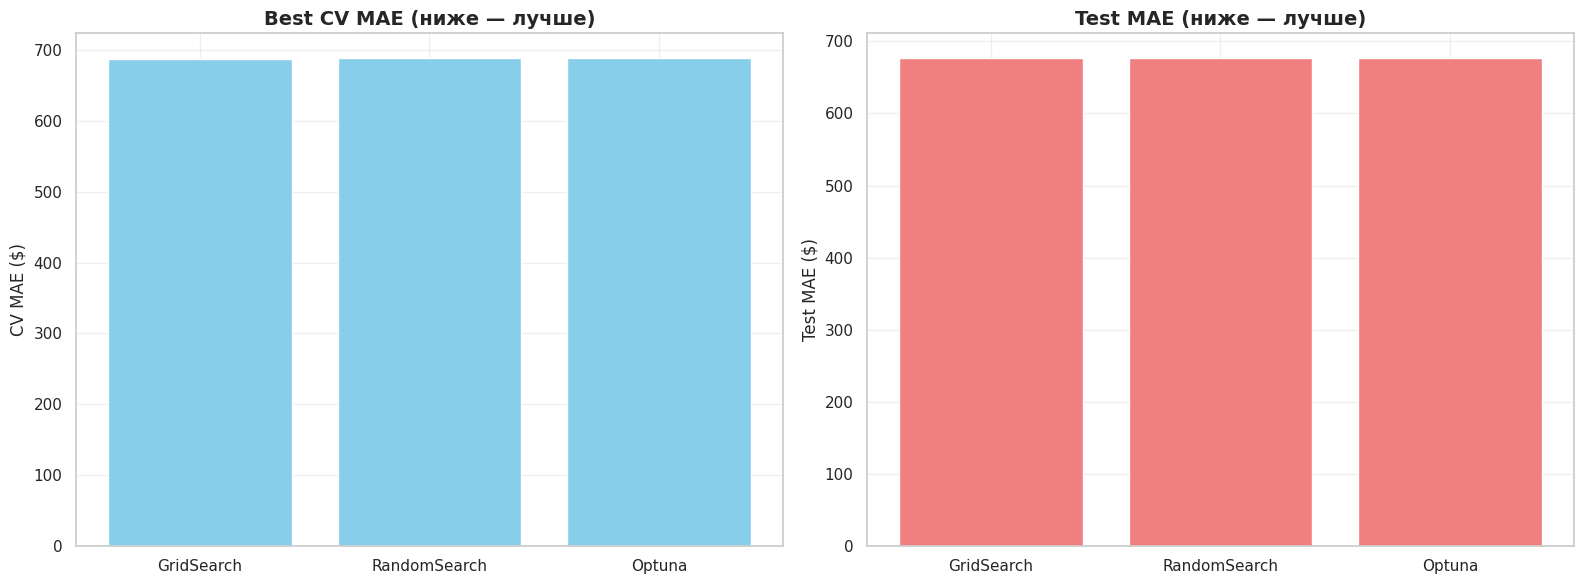


ЛУЧШИЙ МЕТОД: Optuna
  Alpha: 0.000019
  L1 Ratio: 0.9992
  CV MAE: $689.21
  Test MAE: $676.60


In [44]:
# Собираем результаты в DataFrame — все переменные теперь точно определены
tuning_results = pd.DataFrame({
    'Method': ['GridSearch', 'RandomSearch', 'Optuna'],
    'Best Alpha': [
        best_params_grid['alpha'],
        best_params_random['alpha'],
        study.best_params['alpha']
    ],
    'Best L1 Ratio': [
        best_params_grid['l1_ratio'],
        best_params_random['l1_ratio'],
        study.best_params['l1_ratio']
    ],
    'Best CV MAE ($)': [
        best_score_grid,
        best_score_random,
        study.best_value
    ],
    'Test MAE ($)': [
        test_mae_grid,
        test_mae_random,
        test_mae_optuna
    ]
})

print("\nСравнение методов тюнинга:")
print(tuning_results.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CV MAE
axes[0].bar(
    range(len(tuning_results)), 
    tuning_results['Best CV MAE ($)'].values, 
    color='skyblue'
)
axes[0].set_xticks(range(len(tuning_results)))
axes[0].set_xticklabels(tuning_results['Method'].values)
axes[0].set_ylabel('CV MAE ($)')
axes[0].set_title('Best CV MAE (ниже — лучше)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Test MAE
axes[1].bar(
    range(len(tuning_results)), 
    tuning_results['Test MAE ($)'].values, 
    color='lightcoral'
)
axes[1].set_xticks(range(len(tuning_results)))
axes[1].set_xticklabels(tuning_results['Method'].values)
axes[1].set_ylabel('Test MAE ($)')
axes[1].set_title('Test MAE (ниже — лучше)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Определение лучшего метода
best_method_idx = tuning_results['Test MAE ($)'].idxmin()
best_method = tuning_results.loc[best_method_idx]

print(f"\nЛУЧШИЙ МЕТОД: {best_method['Method']}")
print(f"  Alpha: {best_method['Best Alpha']:.6f}")
print(f"  L1 Ratio: {best_method['Best L1 Ratio']:.4f}")
print(f"  CV MAE: ${best_method['Best CV MAE ($)']:.2f}")
print(f"  Test MAE: ${best_method['Test MAE ($)']:.2f}")

## Итоговые выводы по оптимизации гиперпараметров

1. *Победитель:* **Метод байесовской оптимизации Optuna** показал наилучший результат. Учитывая результат метрики MAE(абсолютной ошибки) тестовой выборки производим оценку наилучшей модели - Test MAE - $676. Судя по метрикам, близки фаоритами выступпают Gridsearch / Optuna.
3. *Высокая стабильность (отсутствие переобучения):* Разрыв (gap) между оценкой на кросс-валидации и реальной ошибкой на отложенной тестовой выборке составляет всего ~$11 (менее 1.6%). Это отличный показатель, подтверждающий высокую обобщающую способность модели.
4. *Эффективность поиска:* Grid Search и Random Search показали сопоставимые результаты, что говорит о том, что пространство гиперпараметров для данной задачи имеет выраженный, стабильный глобальный минимум.
5. *Практический итог:* Модель ElasticNet с гиперпараметрами, подобранными через Optuna, является наиболее сбалансированной, стабильной и готовой к интеграции в production-пайплайн для оценки стоимости аренды.